In [ ]:
import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: data.csv                
  inflating: demo1.csv               
  inflating: moisture_days.csv       
  inflating: moisture_time.csv       


In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
df.head()

,crop,moisture,temp,pump
0,cotton,638,16,1
1,cotton,522,18,1
2,cotton,741,22,1
3,cotton,798,32,1
4,cotton,690,28,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   crop      200 non-null    object
 1   moisture  200 non-null    int64 
 2   temp      200 non-null    int64 
 3   pump      200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [ ]:
df.isna().sum()

,0
crop,0
moisture,0
temp,0
pump,0


In [ ]:
df.duplicated().sum()

0

In [ ]:
X = df.drop("pump",axis = 1)
y = df["pump"]

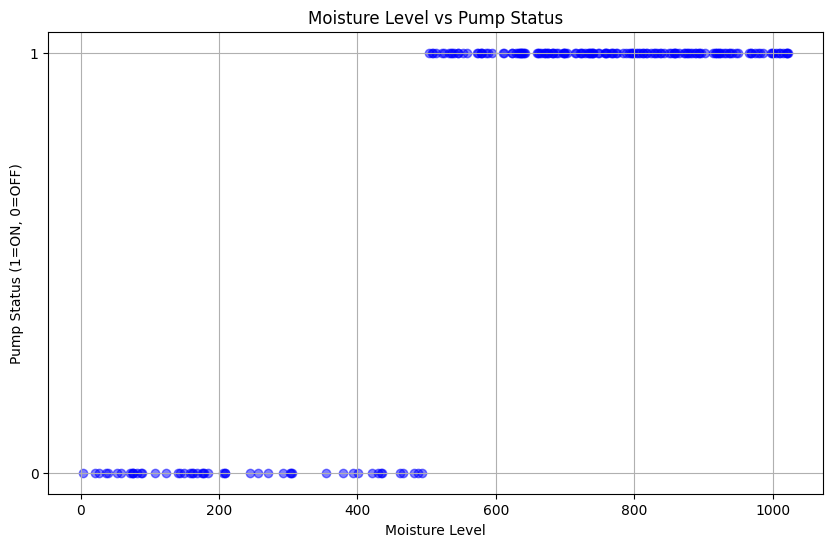

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['moisture'], df['pump'], color='blue', alpha=0.5)


plt.xlabel('Moisture Level')
plt.ylabel('Pump Status (1=ON, 0=OFF)')
plt.title('Moisture Level vs Pump Status')

# Customizing the y-axis to show only 0 and 1
plt.yticks([0, 1])

# Show plot
plt.grid(True)
plt.show()

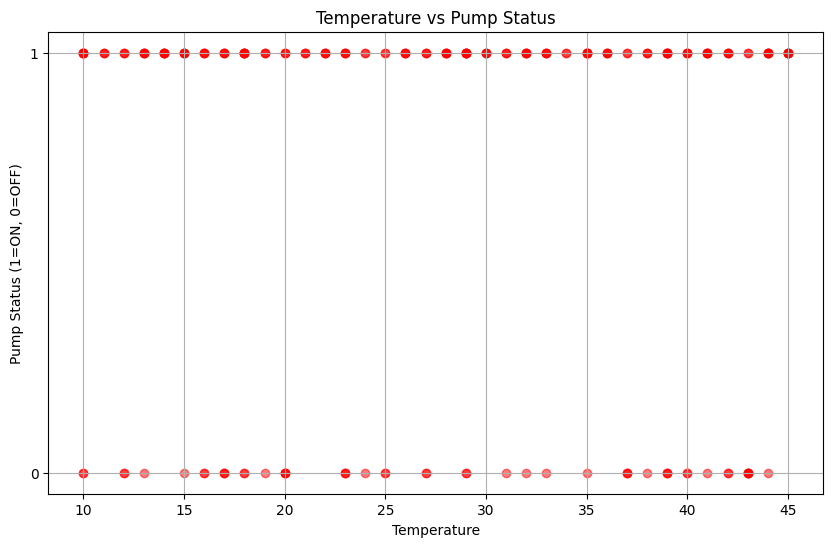

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['temp'], df['pump'], color='red', alpha=0.5)


plt.xlabel('Temperature')
plt.ylabel('Pump Status (1=ON, 0=OFF)')
plt.title('Temperature vs Pump Status')

# Customizing the y-axis to show only 0 and 1
plt.yticks([0, 1])

# Show plot
plt.grid(True)
plt.show()


In [ ]:
X = pd.get_dummies(X)
X.shape

(200, 3)

In [ ]:
#Scaling X
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

classifiers = {
    'RandomForest': RandomForestClassifier(),
    'SVC': SVC(),
    'DecisionTree': DecisionTreeClassifier(),
    'KNeighbors': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(max_iter = 1000),
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy: {accuracy:.4f}")

RandomForest: Accuracy: 1.0000
SVC: Accuracy: 0.9833
DecisionTree: Accuracy: 1.0000
KNeighbors: Accuracy: 0.9667
LogisticRegression: Accuracy: 0.9667


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

RandomForest:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
SVC:
  Accuracy: 0.9833
  Precision: 0.9783
  Recall: 1.0000
  F1-Score: 0.9890
DecisionTree:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
KNeighbors:
  Accuracy: 0.9667
  Precision: 0.9778
  Recall: 0.9778
  F1-Score: 0.9778
LogisticRegression:
  Accuracy: 0.9667
  Precision: 0.9574
  Recall: 1.0000
  F1-Score: 0.9783
